# LUAD Survival Analysis — Cox-Lasso on Gene Expression
**Author:** Parth Shringarpure  
**Date:** June 2026  
**Goal:** Build a Cox-Lasso survival model using 1,000 selected gene expression 
features. This is Model 2 in our baseline ladder — the first model to use 
molecular data rather than clinical variables alone.

**Baseline to beat:** Cox clinical C-index = 0.70

## Step 1: Imports and Setup

In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

os.chdir('/Users/parthshringarpure/Desktop/AI/Projects/luad_survival')

# scikit-survival has Cox-Lasso built in
# install if needed: pip install scikit-survival
from sksurv.linear_model import CoxnetSurvivalAnalysis
from sksurv.preprocessing import OneHotEncoder
from sksurv.metrics import concordance_index_censored
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

print("All imports successful")

All imports successful


## Step 2: Load Data

In [3]:
# Load expression matrix and clinical survival labels
expression = pd.read_csv('data/processed/expression_matrix.csv', index_col=0)
clinical = pd.read_csv('data/processed/clinical_survival.csv', index_col=0)

# Align — keep only patients in both, same order
common = clinical.index.intersection(expression.index)
expression = expression.loc[common]
clinical = clinical.loc[common]

print(f"Patients: {len(common)}")
print(f"Genes:    {expression.shape[1]}")
print(f"Events:   {clinical['event'].sum()} deaths")

Patients: 478
Genes:    1000
Events:   121 deaths


In [4]:
expression.head()

,LINGO2,EPGN,DKK1,CD109,LOC441869,IRX5,DNAH2,INPP5J,FGF5,NTSR1,...,COL8A2,ELOVL2,TMEM61,CXCR5,SLC16A4,SUSD4,PAX8,SEMA4G,LOC643763,OR2W3
tcga-05-4249,0.717123,0.000000,6.223579,9.268900,9.973242,8.468365,9.308264,7.272148,0.402722,0.975190,...,9.206586,4.095739,5.889332,5.236979,7.376462,8.487904,6.736088,7.923409,0.402722,0.000000
tcga-05-4250,1.994326,0.413161,6.969786,11.391548,9.068384,7.934991,7.162424,6.094095,6.072931,4.215244,...,8.421525,6.778239,6.751849,4.783666,10.128589,5.189050,8.056768,9.048185,0.000000,1.999134
tcga-05-4382,1.952930,0.000000,7.572053,10.581265,8.299057,5.897954,8.899220,5.949145,2.591057,4.494249,...,11.109060,5.976817,5.047312,4.927859,8.951063,8.243183,4.759380,8.667964,0.000000,0.968791
tcga-05-4384,0.000000,1.151664,3.969104,9.742851,7.385065,9.798361,9.089258,5.622315,1.151664,1.151664,...,7.803214,4.317384,5.883450,3.509822,10.574716,8.726983,6.598530,7.790612,4.226146,0.000000
tcga-05-4389,2.510456,0.000000,10.219907,8.824478,7.527923,8.781118,6.068400,7.244802,0.417488,0.417488,...,8.473147,3.709346,5.244613,5.773239,8.284192,8.433088,5.971429,8.811315,2.229988,0.417488


In [5]:
clinical.head()

,vital_status,days_to_death,days_to_last_followup,age,gender,stage,survival_time,event,stage_group,age_group
tcga-05-4249,alive,NaN,1158.0,67.0,male,stage ib,1158.0,0,Stage I,≥ 65 years
tcga-05-4250,dead,121.0,NaN,79.0,female,stage iiia,121.0,1,Stage III,≥ 65 years
tcga-05-4382,alive,NaN,607.0,68.0,male,stage ib,607.0,0,Stage I,≥ 65 years
tcga-05-4384,alive,NaN,426.0,66.0,male,stage iiia,426.0,0,Stage III,≥ 65 years
tcga-05-4389,alive,NaN,1369.0,70.0,male,stage ia,1369.0,0,Stage I,≥ 65 years


In [6]:
expression.shape

(478, 1000)

In [7]:
clinical.shape

(478, 10)

## Step 3: Prepare Inputs for Cox-Lasso

scikit-survival requires survival labels in a specific structured array format:
- A numpy array of tuples: (event: bool, survival_time: float)
- Features must be scaled to zero mean and unit variance

In [8]:
# Build structured survival array — required format for scikit-survival
# Each element is a tuple: (did_they_die: bool, survival_time: float)
y = np.array(
    [(bool(e), t) for e, t in zip(clinical['event'], clinical['survival_time'])],
    dtype=[('event', bool), ('survival_time', float)]
)
# Scale expression features — Cox-Lasso is sensitive to feature scale
# StandardScaler: subtracts mean, divides by std → all features on same scale
scaler = StandardScaler()
X = scaler.fit_transform(expression)

print(f"X shape: {X.shape}  (patients × genes)")
print(f"y shape: {y.shape}")
print(f"\nExample survival label: {y[0]}")
print(f"Event rate: {clinical['event'].mean():.1%}")

X shape: (478, 1000)  (patients × genes)
y shape: (478,)

Example survival label: (False, 1158.0)
Event rate: 25.3%


## Step 4: Train/Test Split

We split patients into 80% training and 20% test sets.
The model learns on training data only.
The test set is locked away and only used once at the end to evaluate performance.
This prevents overfitting — the model never sees test patients during training.

In [9]:
from sklearn.model_selection import train_test_split

# First split off 15% test set
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y,
    test_size=0.15,
    random_state=42
)

# Then split remaining 85% into train (70% of total) and val (15% of total)
# 0.15 / 0.85 = 0.176 → gives us ~15% of total as validation
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=0.176,
    random_state=42
)

print(f"Training patients:   {X_train.shape[0]}  (~70%)")
print(f"Validation patients: {X_val.shape[0]}   (~15%)")
print(f"Test patients:       {X_test.shape[0]}   (~15%)")
print(f"Total:               {X_train.shape[0] + X_val.shape[0] + X_test.shape[0]}")

# Check event rates are similar across all three splits
for name, y_split in [('Train', y_train), ('Val', y_val), ('Test', y_test)]:
    events = y_split['event'].sum()
    print(f"\n{name} events: {events} ({events/len(y_split):.1%})")

Training patients:   334  (~70%)
Validation patients: 72   (~15%)
Test patients:       72   (~15%)
Total:               478

Train events: 85 (25.4%)

Val events: 17 (23.6%)

Test events: 19 (26.4%)


## Step 5: Fit Cox-Lasso — Find Best Alpha

We try multiple alpha values (Lasso penalty strength).
For each alpha we fit on training data and evaluate on validation data.
The alpha giving the best validation C-index is our chosen model.

In [10]:
from sksurv.linear_model import CoxnetSurvivalAnalysis
from sksurv.metrics import concordance_index_censored

# Alpha values to try — from very weak to very strong penalty
# np.logspace gives evenly spaced values on a log scale
alphas = np.logspace(-4, 0, 30)  # 30 values from 0.0001 to 1.0

val_cindex = []  # store validation C-index for each alpha

print("Searching for best alpha...")
print("Alpha        Val C-index")
print("-" * 30)

for alpha in alphas:
    try:
        # Fit Cox-Lasso on training data
        model = CoxnetSurvivalAnalysis(
            l1_ratio=1.0,        # 1.0 = pure Lasso (no Ridge mixing)
            alphas=[alpha],      # penalty strength
            fit_baseline_model=True
        )
        model.fit(X_train, y_train)

        # Predict risk scores on validation set
        risk_scores = model.predict(X_val)

        # Calculate C-index on validation set
        cindex = concordance_index_censored(
            y_val['event'],
            y_val['survival_time'],
            risk_scores
        )[0]

        val_cindex.append(cindex)

        if len(val_cindex) % 5 == 0:
            print(f"{alpha:.5f}    {cindex:.4f}")

    except Exception:
        val_cindex.append(0.5)

# Find best alpha
best_idx   = np.argmax(val_cindex)
best_alpha = alphas[best_idx]
best_cindex = val_cindex[best_idx]

print(f"\nBest alpha:         {best_alpha:.6f}")
print(f"Best val C-index:   {best_cindex:.4f}")

Searching for best alpha...
Alpha        Val C-index
------------------------------
0.00036    0.4483
0.00174    0.4581
0.00853    0.7906
0.04175    0.7266
0.20434    0.5000
1.00000    0.5000

Best alpha:         0.008532
Best val C-index:   0.7906


## Step 6: Evaluate Best Model on Test Set

We refit the best alpha on training data and evaluate 
on the held-out test set — the only unbiased estimate 
of true model performance.

In [11]:
# Refit best model on training data
best_model = CoxnetSurvivalAnalysis(
    l1_ratio=1.0,
    alphas=[best_alpha],
    fit_baseline_model=True
)
best_model.fit(X_train, y_train)

# Evaluate on test set
test_risk = best_model.predict(X_test)
test_cindex = concordance_index_censored(
    y_test['event'],
    y_test['survival_time'],
    test_risk
)[0]

# Evaluate on train set — to check for overfitting
train_risk = best_model.predict(X_train)
train_cindex = concordance_index_censored(
    y_train['event'],
    y_train['survival_time'],
    train_risk
)[0]

print(f"{'='*45}")
print(f"COX-LASSO RESULTS SUMMARY")
print(f"{'='*45}")
print(f"Best alpha:          {best_alpha:.6f}")
print(f"Train C-index:       {train_cindex:.4f}")
print(f"Validation C-index:  {best_cindex:.4f}")
print(f"Test C-index:        {test_cindex:.4f}")
print(f"{'='*45}")
print(f"\nBaseline (Cox clinical): 0.7001")
print(f"Cox-Lasso (expression):  {test_cindex:.4f}")
diff = test_cindex - 0.7001
print(f"Difference:              {diff:+.4f}")

COX-LASSO RESULTS SUMMARY
Best alpha:          0.008532
Train C-index:       0.8505
Validation C-index:  0.7906
Test C-index:        0.5522

Baseline (Cox clinical): 0.7001
Cox-Lasso (expression):  0.5522
Difference:              -0.1479


## Step 7: Refit with Cross-Validation Alpha Selection

Our single validation split (72 patients, 17 events) was too small 
to reliably estimate the best alpha. 

We switch to 5-fold cross-validation across the full training set.
This means for each alpha, we fit and evaluate 5 times on different 
splits and average the C-index — a much more stable estimate.

In [12]:
from sklearn.model_selection import KFold

# 5-fold cross-validation on training set only
kf = KFold(n_splits=5, shuffle=True, random_state=42)
alphas = np.logspace(-4, 0, 30)

# For each alpha, store C-index from each fold
cv_results = {alpha: [] for alpha in alphas}

print("Running 5-fold cross-validation across 30 alpha values...")
print("This may take 2-3 minutes...\n")

for fold, (train_idx, val_idx) in enumerate(kf.split(X_train)):
    
    X_fold_train = X_train[train_idx]
    y_fold_train = y_train[train_idx]
    X_fold_val   = X_train[val_idx]
    y_fold_val   = y_train[val_idx]
    
    for alpha in alphas:
        try:
            model = CoxnetSurvivalAnalysis(
                l1_ratio=1.0,
                alphas=[alpha],
                fit_baseline_model=True
            )
            model.fit(X_fold_train, y_fold_train)
            risk = model.predict(X_fold_val)
            cindex = concordance_index_censored(
                y_fold_val['event'],
                y_fold_val['survival_time'],
                risk
            )[0]
            cv_results[alpha].append(cindex)
        except Exception:
            cv_results[alpha].append(0.5)
    
    print(f"Fold {fold+1} complete")

# Average C-index across folds for each alpha
mean_cindex = {alpha: np.mean(scores) for alpha, scores in cv_results.items()}

# Best alpha
best_alpha_cv = max(mean_cindex, key=mean_cindex.get)
best_cv_cindex = mean_cindex[best_alpha_cv]

print(f"\nBest alpha (CV):     {best_alpha_cv:.6f}")
print(f"Best CV C-index:     {best_cv_cindex:.4f}")

Running 5-fold cross-validation across 30 alpha values...
This may take 2-3 minutes...

Fold 1 complete
Fold 2 complete
Fold 3 complete
Fold 4 complete
Fold 5 complete

Best alpha (CV):     0.022122
Best CV C-index:     0.6328


## Step 8: Evaluate CV Model on Test Set

In [13]:
# Refit using CV-selected alpha on full training set
best_model_cv = CoxnetSurvivalAnalysis(
    l1_ratio=1.0,
    alphas=[best_alpha_cv],
    fit_baseline_model=True
)
best_model_cv.fit(X_train, y_train)

# Evaluate on all three sets
train_risk = best_model_cv.predict(X_train)
val_risk   = best_model_cv.predict(X_val)
test_risk  = best_model_cv.predict(X_test)

train_cindex = concordance_index_censored(y_train['event'], y_train['survival_time'], train_risk)[0]
val_cindex   = concordance_index_censored(y_val['event'],   y_val['survival_time'],   val_risk)[0]
test_cindex  = concordance_index_censored(y_test['event'],  y_test['survival_time'],  test_risk)[0]

# How many genes did Lasso keep?
coefs = best_model_cv.coef_.flatten()
n_genes_kept = np.sum(coefs != 0)

print(f"{'='*50}")
print(f"COX-LASSO (CV) RESULTS SUMMARY")
print(f"{'='*50}")
print(f"Best alpha (CV):      {best_alpha_cv:.6f}")
print(f"Genes kept by Lasso:  {n_genes_kept} / 1000")
print(f"Train C-index:        {train_cindex:.4f}")
print(f"Val C-index:          {val_cindex:.4f}")
print(f"Test C-index:         {test_cindex:.4f}")
print(f"{'='*50}")
print(f"\nBaseline Cox clinical:  0.7001")
print(f"Cox-Lasso expression:   {test_cindex:.4f}")
print(f"Difference:             {test_cindex - 0.7001:+.4f}")

COX-LASSO (CV) RESULTS SUMMARY
Best alpha (CV):      0.022122
Genes kept by Lasso:  72 / 1000
Train C-index:        0.9135
Val C-index:          0.7315
Test C-index:         0.6493

Baseline Cox clinical:  0.7001
Cox-Lasso expression:   0.6493
Difference:             -0.0508


## Step 9: Inspect and Save Results

We examine which 72 genes Cox-Lasso kept and save results.
These genes are biologically interpretable survival markers —
each has a coefficient directly interpretable as a hazard ratio direction.

Genes kept by Lasso: 72

Top 20 most important genes:
         gene  coefficient
0       NCAM2     0.412907
1     PKHD1L1    -0.359353
2       HOXB9     0.312693
3       CNTN3    -0.260971
4       KCNA6    -0.227340
5        EPGN     0.214242
6      ZNF257    -0.213856
7     ADAMTS1     0.209217
8       WFDC3    -0.202800
9    HIST1H3G    -0.197523
10      GSTT2    -0.192145
11    SLCO1B1     0.185950
12       GPC6     0.168341
13    TMEM139     0.155578
14      PCSK9     0.141263
15     HS3ST2    -0.133799
16    TMEM215    -0.131127
17       GAS2     0.130920
18      HTR2B    -0.128360
19  LOC654433     0.127362


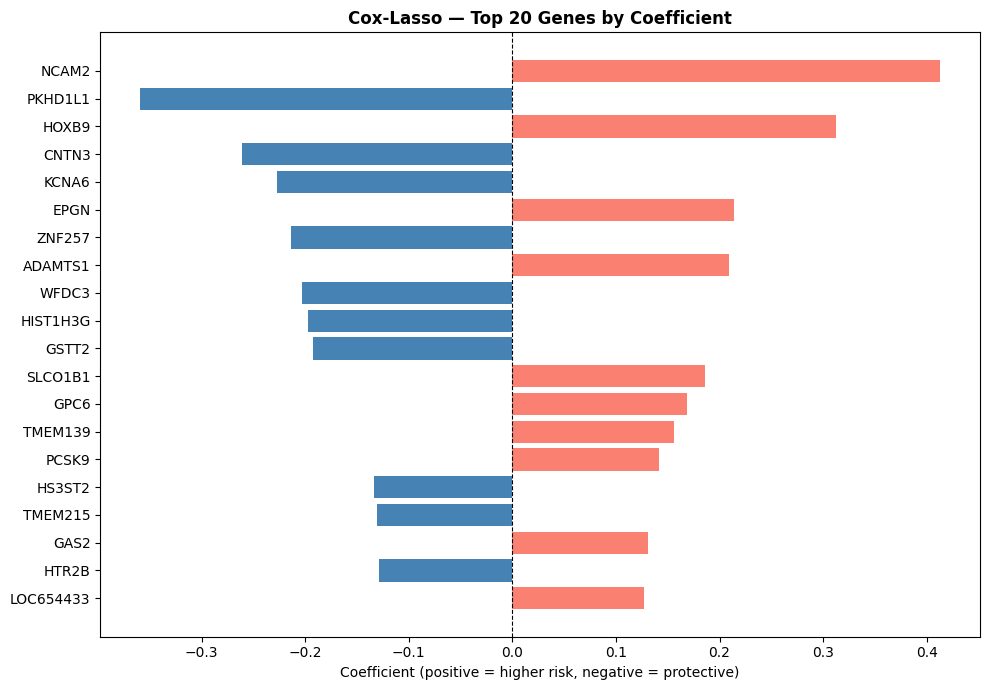


Saved: outputs/figures/04_cox_lasso_genes.png
Saved: outputs/results/cox_lasso_coefficients.csv
Saved: outputs/results/cox_lasso_performance.csv


In [14]:
# Get gene names from expression dataframe
gene_names = expression.columns.tolist()

# Build results dataframe — gene name + coefficient
coef_df = pd.DataFrame({
    'gene'       : gene_names,
    'coefficient': coefs
})

# Keep only genes Lasso didn't shrink to zero
coef_df = coef_df[coef_df['coefficient'] != 0]
coef_df = coef_df.reindex(coef_df['coefficient'].abs().sort_values(ascending=False).index)
coef_df = coef_df.reset_index(drop=True)

print(f"Genes kept by Lasso: {len(coef_df)}")
print(f"\nTop 20 most important genes:")
print(coef_df.head(20).to_string())

# Plot top 20 genes
fig, ax = plt.subplots(figsize=(10, 7))
colors = ['salmon' if c > 0 else 'steelblue' for c in coef_df.head(20)['coefficient']]
ax.barh(coef_df.head(20)['gene'], coef_df.head(20)['coefficient'], color=colors)
ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_title('Cox-Lasso — Top 20 Genes by Coefficient', fontweight='bold')
ax.set_xlabel('Coefficient (positive = higher risk, negative = protective)')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('outputs/figures/04_cox_lasso_genes.png', dpi=150, bbox_inches='tight')
plt.show()

# Save results
coef_df.to_csv('outputs/results/cox_lasso_coefficients.csv', index=False)

# Save model performance
perf = pd.DataFrame({
    'model'   : ['Cox-Lasso Expression'],
    'features': ['72 genes (from 1000)'],
    'train_cindex': [train_cindex],
    'val_cindex'  : [val_cindex],
    'test_cindex' : [test_cindex]
})
perf.to_csv('outputs/results/cox_lasso_performance.csv', index=False)

print(f"\nSaved: outputs/figures/04_cox_lasso_genes.png")
print(f"Saved: outputs/results/cox_lasso_coefficients.csv")
print(f"Saved: outputs/results/cox_lasso_performance.csv")